# 👥 Perfiles de 8 Clusters (k=8 Optimizado)

**Objetivo**: Crear perfiles interpretativos para los 8 clusters optimizados

**Output**:
- Perfiles de 8 clusters
- Nombres de negocio
- Recomendaciones
- Archivos guardados con sufijo `_k8`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

## 1. Cargar Datos y Modelo k=8

In [2]:
# Cargar datos originales
df_raw = pd.read_csv('../../clustering/data/df_for_clustering.csv')
df_raw.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')
df_raw = df_raw[df_raw['deceased'] == 'N']

print(f"Datos cargados: {df_raw.shape}")

Datos cargados: (442909, 23)


In [3]:
# Cargar modelos
pca = joblib.load('../../clustering/models/pca_model.pkl')
kmeans = joblib.load('../models/kmeans_k8.pkl')  # Modelo k=8

print(f"Modelo k=8 cargado: {kmeans.n_clusters} clusters")

Modelo k=8 cargado: 8 clusters


/Users/alex/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.2.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## 2. Aplicar Clustering k=8

In [4]:
# Preprocesamiento (mismo que entrenamiento)
df = df_raw.copy()

df.drop(columns=['deceased', 'gender', 'entry_channel'], inplace=True, errors='ignore')
df.drop(columns=['z_pct_months_active', 'account', 'z_num_families'], inplace=True, errors='ignore')
df.drop(columns=['macro_region', 'is_coast'], inplace=True, errors='ignore')

df_ids = df[['pk_cid', 'pk_partition']].copy()
df.drop(columns=['pk_cid', 'pk_partition'], inplace=True)

# OHE
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

def one_hot_encode(df, features):
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    encoded = encoder.fit_transform(df[features])
    encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(features), index=df.index)
    df = df.drop(columns=features)
    return pd.concat([df, encoded_df], axis=1)

df = one_hot_encode(df, ['segment', 'city_size'])

# Normalizar
scaler = MinMaxScaler()
df[['age', 'salary', 'z_months_since_entry', 'z_num_products']] = scaler.fit_transform(
    df[['age', 'salary', 'z_months_since_entry', 'z_num_products']]
)

# PCA
X_pca = pca.transform(df)

# Predecir clusters
clusters = kmeans.predict(X_pca) + 1  # +1 para que empiecen en 1

print(f"✅ Clusters k=8 asignados")
print(f"Distribución:\n{pd.Series(clusters).value_counts().sort_index()}")

✅ Clusters k=8 asignados
Distribución:
1    49104
2    79071
3    48934
4    52933
5    81893
6    45095
7    47953
8    37926
Name: count, dtype: int64


In [5]:
# Añadir cluster al dataframe
df_raw['cluster'] = clusters

## 3. Perfiles por Cluster (8 clusters)

In [6]:
profile_vars = [
    'age', 'salary', 'z_months_since_entry', 'z_num_products',
    'active_customer', 'pension_plan', 'payment_card', 'loan', 'investment'
]

profiles = df_raw.groupby('cluster')[profile_vars].agg(['mean', 'median']).round(2)

print("📊 PERFILES POR CLUSTER (k=8)\n")
print(profiles)

📊 PERFILES POR CLUSTER (k=8)

          age           salary           z_months_since_entry         \
         mean median      mean    median                 mean median   
cluster                                                                
1       24.44  23.00  93321.81  81780.82                25.03  22.00   
2       24.07  23.00 113125.45  85674.09                27.24  30.00   
3       40.61  39.00 109830.52  88329.09                24.62  23.00   
4       43.01  40.00 120663.40 104212.08                22.08  20.00   
5       23.81  23.00  87594.44  78302.37                25.80  22.00   
6       23.80  22.00 137800.03 125047.20                19.49  18.00   
7       42.35  40.00  87014.65  78090.81                22.26  20.00   
8       27.43  24.00 128287.54 108560.26                22.53  20.00   

        z_num_products        active_customer        pension_plan         \
                  mean median            mean median         mean median   
cluster                  

In [7]:
# Tamaño de clusters
sizes = df_raw.groupby('cluster').size().to_frame('size')
sizes['%'] = (sizes['size'] / sizes['size'].sum() * 100).round(1)

print("\n📏 TAMAÑO DE CLUSTERS (k=8)\n")
print(sizes)


📏 TAMAÑO DE CLUSTERS (k=8)

          size     %
cluster             
1        49104 11.10
2        79071 17.90
3        48934 11.00
4        52933 12.00
5        81893 18.50
6        45095 10.20
7        47953 10.80
8        37926  8.60


In [8]:
# Segmento y género predominante
segment_mode = df_raw.groupby('cluster')['segment'].agg(lambda x: x.mode()[0])
gender_mode = df_raw.groupby('cluster')['gender'].agg(lambda x: x.mode()[0])

cluster_chars = pd.DataFrame({
    'size': sizes['size'],
    '%': sizes['%'],
    'segmento_principal': segment_mode,
    'genero_predominante': gender_mode
})

print("\n🎯 CARACTERÍSTICAS PRINCIPALES (k=8)\n")
print(cluster_chars)


🎯 CARACTERÍSTICAS PRINCIPALES (k=8)

          size     %  segmento_principal genero_predominante
cluster                                                     
1        49104 11.10  03 - UNIVERSITARIO                   H
2        79071 17.90  03 - UNIVERSITARIO                   H
3        48934 11.00   02 - PARTICULARES                   V
4        52933 12.00   02 - PARTICULARES                   V
5        81893 18.50  03 - UNIVERSITARIO                   H
6        45095 10.20  03 - UNIVERSITARIO                   H
7        47953 10.80   02 - PARTICULARES                   V
8        37926  8.60  03 - UNIVERSITARIO                   H


## 4. Análisis Detallado de cada Cluster

In [9]:
# Analizar cada uno de los 8 clusters
for cluster_id in sorted(df_raw['cluster'].unique()):
    cluster_data = df_raw[df_raw['cluster'] == cluster_id]
    
    print(f"\n{'='*60}")
    print(f"CLUSTER {cluster_id} ({len(cluster_data):,} clientes, {len(cluster_data)/len(df_raw)*100:.1f}%)")
    print(f"{'='*60}")
    
    print(f"Edad promedio: {cluster_data['age'].mean():.0f} años")
    print(f"Salario promedio: {cluster_data['salary'].mean():,.0f} €")
    print(f"Antigüedad promedio: {cluster_data['z_months_since_entry'].mean():.0f} meses")
    print(f"N° productos promedio: {cluster_data['z_num_products'].mean():.1f}")
    print(f"% Activos: {cluster_data['active_customer'].mean()*100:.1f}%")
    print(f"% con pension_plan: {cluster_data['pension_plan'].mean()*100:.1f}%")
    print(f"% con payment_card: {cluster_data['payment_card'].mean()*100:.1f}%")
    print(f"Segmento principal: {cluster_data['segment'].mode()[0]}")
    print(f"Género predominante: {cluster_data['gender'].mode()[0]}")


CLUSTER 1 (49,104 clientes, 11.1%)
Edad promedio: 24 años
Salario promedio: 93,322 €
Antigüedad promedio: 25 meses
N° productos promedio: 0.9
% Activos: 33.3%
% con pension_plan: 1.2%
% con payment_card: 3.7%
Segmento principal: 03 - UNIVERSITARIO
Género predominante: H

CLUSTER 2 (79,071 clientes, 17.9%)
Edad promedio: 24 años
Salario promedio: 113,125 €
Antigüedad promedio: 27 meses
N° productos promedio: 1.0
% Activos: 0.0%
% con pension_plan: 0.0%
% con payment_card: 0.1%
Segmento principal: 03 - UNIVERSITARIO
Género predominante: H

CLUSTER 3 (48,934 clientes, 11.0%)
Edad promedio: 41 años
Salario promedio: 109,831 €
Antigüedad promedio: 25 meses
N° productos promedio: 0.2
% Activos: 5.8%
% con pension_plan: 0.0%
% con payment_card: 0.0%
Segmento principal: 02 - PARTICULARES
Género predominante: V

CLUSTER 4 (52,933 clientes, 12.0%)
Edad promedio: 43 años
Salario promedio: 120,663 €
Antigüedad promedio: 22 meses
N° productos promedio: 2.0
% Activos: 99.8%
% con pension_plan: 15.0

## 5. Asignar Nombres de Negocio

**IMPORTANTE**: Revisa el output anterior y asigna nombres descriptivos apropiados

In [10]:
# PLACEHOLDER - Ajustar según el análisis real
cluster_names = {
    1: "Universitarios Estándar",        # 24 años, €93k, 0.94 productos, 33% activos
    2: "Inactivos Totales",              # 24 años, €113k, 0% activos, 0.4% propensión - ABANDONAR
    3: "Profesionales Dormidos",         # 41 años, €110k, 6% activos, 4.4% propensión - RECUPERAR
    4: "Alto Valor Principal",           # ⭐⭐⭐ 43 años, €121k, 100% activos, 13% propensión - FOCO #1
    5: "Jóvenes Activos Básicos",        # 24 años, €88k, 35% activos, 1.2% propensión
    6: "Alto Potencial Virgen",          # 💎 24 años, €138k, 0 productos, 1% activos - ONBOARDING AGRESIVO
    7: "Valor Medio-Alto",               # ⭐⭐ 42 años, €87k, 68% activos, 10.2% propensión - FOCO #2
    8: "Emergentes Premium"              # ⭐ 27 años, €128k, 100% activos, 6% propensión - NURTURING
}

# NOTA: Estos nombres son placeholders. Revisa el output de la celda anterior
# y asigna nombres descriptivos (ej: "Jóvenes Activos", "Premium con Pensión", etc.)

df_raw['cluster_name'] = df_raw['cluster'].map(cluster_names)

print("\n🏷️ NOMBRES ASIGNADOS (k=8):\n")
for k, v in cluster_names.items():
    size = len(df_raw[df_raw['cluster']==k])
    pct = size/len(df_raw)*100
    print(f"Cluster {k}: {v:30s} ({size:,} clientes, {pct:.1f}%)")


🏷️ NOMBRES ASIGNADOS (k=8):

Cluster 1: Universitarios Estándar        (49,104 clientes, 11.1%)
Cluster 2: Inactivos Totales              (79,071 clientes, 17.9%)
Cluster 3: Profesionales Dormidos         (48,934 clientes, 11.0%)
Cluster 4: Alto Valor Principal           (52,933 clientes, 12.0%)
Cluster 5: Jóvenes Activos Básicos        (81,893 clientes, 18.5%)
Cluster 6: Alto Potencial Virgen          (45,095 clientes, 10.2%)
Cluster 7: Valor Medio-Alto               (47,953 clientes, 10.8%)
Cluster 8: Emergentes Premium             (37,926 clientes, 8.6%)


## 6. Penetración de Productos


📊 PENETRACIÓN DE PRODUCTOS POR CLUSTER (k=8) (%)

         pension_plan  payment_card  loan  investment
cluster                                              
1                1.20          3.70  0.00        0.80
2                0.00          0.10  0.00        0.00
3                0.00          0.00  0.00        0.00
4               15.00         39.80  0.10        7.50
5                1.10          3.90  0.00        0.10
6                0.00          0.00  0.00        0.00
7                8.90         24.00  0.00        4.80
8                9.60         18.90  0.00        4.70


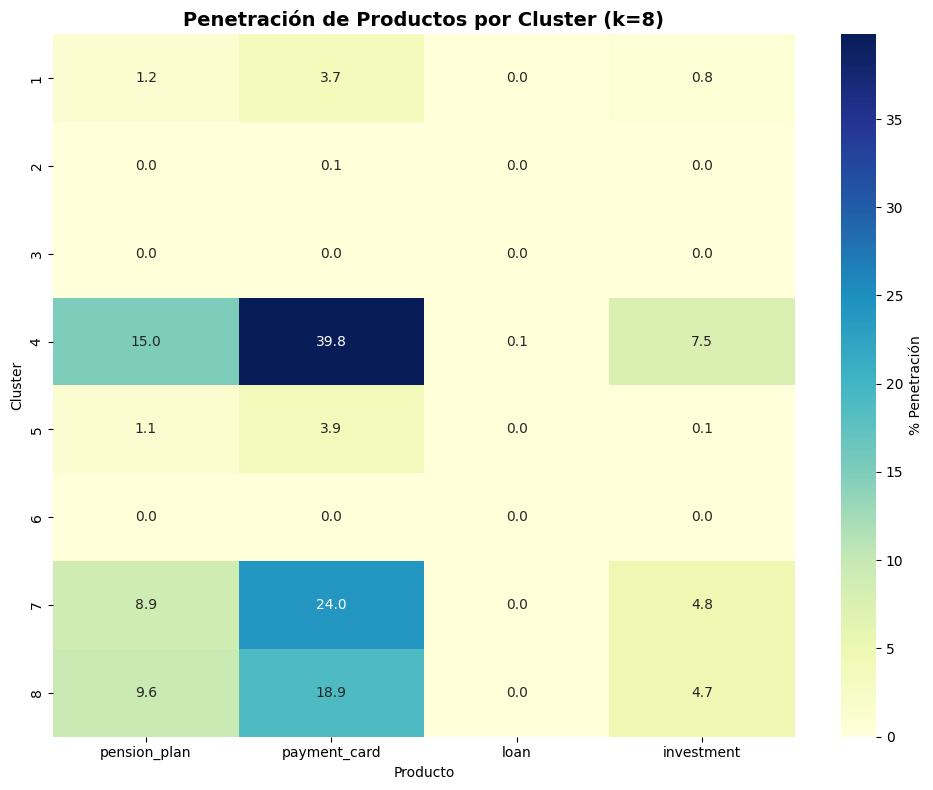

In [11]:
productos = ['pension_plan', 'payment_card', 'loan', 'investment']

penetracion = df_raw.groupby('cluster')[productos].mean() * 100
penetracion = penetracion.round(1)

print("\n📊 PENETRACIÓN DE PRODUCTOS POR CLUSTER (k=8) (%)\n")
print(penetracion)

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(penetracion, annot=True, fmt='.1f', cmap='YlGnBu', cbar_kws={'label': '% Penetración'})
plt.title('Penetración de Productos por Cluster (k=8)', fontsize=14, fontweight='bold')
plt.ylabel('Cluster')
plt.xlabel('Producto')
plt.tight_layout()
plt.savefig('../visualizations/product_penetration_heatmap_k8.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Recomendaciones Automáticas

In [12]:
recomendaciones = {}

for cluster_id in sorted(df_raw['cluster'].unique()):
    cluster_data = df_raw[df_raw['cluster'] == cluster_id]
    recos = []
    
    if cluster_data['active_customer'].mean() < 0.5:
        recos.append("Campaña de reactivación urgente")
    
    if cluster_data['pension_plan'].mean() < 0.1:
        recos.append("Oportunidad cross-sell: Pension Plan")
    
    if cluster_data['payment_card'].mean() < 0.3:
        recos.append("Oportunidad cross-sell: Payment Card")
    
    if cluster_data['salary'].mean() > 100000 and cluster_data['z_num_products'].mean() < 2:
        recos.append("Segmento premium sub-utilizado: up-sell")
    
    if cluster_data['z_months_since_entry'].mean() < 12:
        recos.append("Clientes nuevos: programa bienvenida")
    
    recomendaciones[cluster_id] = recos

print("\n💡 RECOMENDACIONES POR CLUSTER (k=8)\n")
for cluster_id, recos in recomendaciones.items():
    print(f"\nCluster {cluster_id} - {cluster_names[cluster_id]}:")
    if recos:
        for i, reco in enumerate(recos, 1):
            print(f"  {i}. {reco}")
    else:
        print("  • Mantener estrategia actual")


💡 RECOMENDACIONES POR CLUSTER (k=8)


Cluster 1 - Universitarios Estándar:
  1. Campaña de reactivación urgente
  2. Oportunidad cross-sell: Pension Plan
  3. Oportunidad cross-sell: Payment Card

Cluster 2 - Inactivos Totales:
  1. Campaña de reactivación urgente
  2. Oportunidad cross-sell: Pension Plan
  3. Oportunidad cross-sell: Payment Card
  4. Segmento premium sub-utilizado: up-sell

Cluster 3 - Profesionales Dormidos:
  1. Campaña de reactivación urgente
  2. Oportunidad cross-sell: Pension Plan
  3. Oportunidad cross-sell: Payment Card
  4. Segmento premium sub-utilizado: up-sell

Cluster 4 - Alto Valor Principal:
  1. Segmento premium sub-utilizado: up-sell

Cluster 5 - Jóvenes Activos Básicos:
  1. Campaña de reactivación urgente
  2. Oportunidad cross-sell: Pension Plan
  3. Oportunidad cross-sell: Payment Card

Cluster 6 - Alto Potencial Virgen:
  1. Campaña de reactivación urgente
  2. Oportunidad cross-sell: Pension Plan
  3. Oportunidad cross-sell: Payment Card
  4. S

## 8. Guardar Resultados (con sufijo _k8)

In [13]:
# Guardar con sufijo _k8
df_raw[['pk_cid', 'cluster', 'cluster_name']].to_csv('../data/customer_clusters_k8.csv', index=False)
profiles.to_csv('../data/cluster_profiles_k8.csv')
penetracion.to_csv('../data/product_penetration_k8.csv')

recos_df = pd.DataFrame([
    {'cluster': k, 'cluster_name': cluster_names[k], 'recomendaciones': '; '.join(v)}
    for k, v in recomendaciones.items()
])
recos_df.to_csv('../data/cluster_recommendations_k8.csv', index=False)

print("✅ Resultados k=8 guardados en ../data/ con sufijo _k8")

✅ Resultados k=8 guardados en ../data/ con sufijo _k8
